# Advanced: Propagating SIM Parameter Uncertainty into a Portfolio
The single index model parameters that L6b's examples load are estimates with the standard errors L6a computed, and a portfolio built from them inherits that uncertainty in a nonlinear way: narrow intervals on every beta do not imply stable weights. In this optional notebook, we bootstrap the SIM parameters of a small universe two ways (empirical residuals and Gaussian innovations), keep each asset's joint draw of intercept, beta, and residual scale, rebuild the SIM mean vector and covariance matrix for every draw, and read the resulting distributions of portfolio volatility, allocation distance, and variance regret for a fixed minimum-variance allocation. This is the executable counterpart of the propagation section of the L6a advanced theory notebook.

> __Learning Objectives:__
>
> By the end of this notebook, you should be able to:
> * __Bootstrap SIM parameters jointly:__ Resample the fitted model for each asset with empirical residuals and with Gaussian innovations, and keep the intercept, beta, and residual scale of each replicate together, so that their within-fit dependence is preserved.
> * __Propagate draws into portfolio inputs and decisions:__ Rebuild the SIM covariance matrix for every joint draw, hold a calibrated allocation fixed, and measure how its variance, its distance from the scenario-optimal allocation, and its variance regret vary across draws.
> * __Read the limits of the exercise:__ Say what the residual-versus-parametric gap diagnoses, why the propagated distributions are estimation uncertainty rather than forecasts, and which dependence the independent-draws design leaves out.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file in this folder activates the course project and loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/). For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We use the training data of the L6a and L6b examples, daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, loaded by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keeping the securities with the maximum number of trading days, and building the growth-rate matrix [using the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). The market series is the SPY column, and its training-period sample mean and standard deviation are the market moments (the same numbers the L6a archive stores). We store the cleaned data in `dataset::Dict{String,DataFrame}`, the growth-rate matrix in `G::Array{Float64,2}`, and the market series in `g_market::Array{Float64,1}`:

In [2]:
dataset, list_of_tickers, G, g_market = let
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict(ticker => data for (ticker, data) ∈ original_dataset if nrow(data) == maximum_number_trading_days);
    list_of_tickers = keys(dataset) |> collect |> sort;
    G = log_growth_matrix(dataset, list_of_tickers, Δt = 1/252); # growth rates g (units: 1/years)
    g_market = G[:, findfirst(==("SPY"), list_of_tickers)]; # market growth rates g_M,t
    (dataset, list_of_tickers, G, g_market); # return
end;
println("$(length(list_of_tickers)) securities, N = $(length(g_market)) training days")

424 securities, N = 2766 training days


### Constants
Let's specify the constants used below: the small universe (deliberately small enough to inspect), the market moments, the bootstrap and scenario counts, and the seeds that make the notebook deterministic:

In [3]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
my_list_of_tickers = ["AAPL", "AMD", "JPM", "MSFT", "NVDA", "XOM"]; # a six-firm universe: technology, semiconductors, a bank, and an oil major
g_market_mean = mean(g_market); # training-period market mean g′_M (units: 1/years)
σ_market = std(g_market); # training-period market growth-rate standard deviation s_g,M (units: 1/years)
number_of_bootstrap_samples = 750; # bootstrap replicates per asset
number_of_scenarios = 1500; # joint parameter scenarios propagated into the portfolio
base_seed = 5660; # seeds are base_seed + offsets below, so every run of this notebook gives the same numbers

___

## Task 1: A Bootstrap Distribution for Every Asset
For each firm we fit the SIM against SPY and bootstrap it two ways [using the `bootstrap_sim(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) of the course package (the function of the L6a uncertainty example): `method = :residual` resamples the centered fitted residuals and keeps their heavy-tailed shape, `method = :parametric` draws Gaussian innovations with the fitted residual standard deviation. Every replicate returns the joint triple $(\hat{\alpha}^{(b)},\hat{\beta}^{(b)},s^{(b)}_{g,\varepsilon})$, and we keep each row together: sampling the three marginals independently would discard the within-fit dependence between them. We store the results in the `residual_results` and `parametric_results` arrays (one entry per firm) and print the point estimates:

In [4]:
residual_results, parametric_results = let
    asset_series = [G[:, findfirst(==(ticker), list_of_tickers)] for ticker ∈ my_list_of_tickers];
    residual_results = [bootstrap_sim(g_market, asset_series[i], my_list_of_tickers[i];
        n_bootstrap = number_of_bootstrap_samples, seed = base_seed + i, method = :residual) for i ∈ eachindex(my_list_of_tickers)];
    parametric_results = [bootstrap_sim(g_market, asset_series[i], my_list_of_tickers[i];
        n_bootstrap = number_of_bootstrap_samples, seed = base_seed + 100 + i, method = :parametric) for i ∈ eachindex(my_list_of_tickers)];
    (residual_results, parametric_results); # return
end;

let
    df = DataFrame(ticker = my_list_of_tickers,
        α̂ = round.([r.point_estimate.α for r ∈ residual_results], digits=4),
        β̂ = round.([r.point_estimate.β for r ∈ residual_results], digits=4),
        s_ε = round.([r.point_estimate.σ_ε for r ∈ residual_results], digits=3),
        R² = round.([r.point_estimate.r² for r ∈ residual_results], digits=3),
        β_CI_width = round.([r.confidence_intervals.beta[2] - r.confidence_intervals.beta[1] for r ∈ residual_results], digits=4));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- --------- ------------
  ticker         α̂         β̂       s_ε        R²   β_CI_width 
  String   Float64   Float64   Float64   Float64      Float64 
 -------- --------- --------- --------- --------- ------------
    AAPL    0.1061    1.1946     2.701     0.474       0.0948
     AMD    0.1275    1.7392     6.541     0.245       0.2403
     JPM    0.0005    1.2044     2.676     0.483       0.0942
    MSFT    0.0999     1.152     2.366     0.522        0.076
    NVDA    0.3468    1.7493     4.898      0.37        0.171
     XOM   -0.0941    0.9505     3.222     0.286       0.1118
 -------- --------- --------- --------- --------- ------------


The `s_ε` column is the residual growth-rate standard deviation $s_{g,\varepsilon}$ (units: inverse years) and `β_CI_width` is the width of the residual-bootstrap 95% interval for beta. Every beta interval is narrow relative to its beta, a tenth or two wide, which is the point of what follows: modest parameter intervals are the input, and the question is what comes out at the portfolio level.
___

## Task 2: The Calibrated Portfolio
Under the growth-rate convention of the lecture the SIM inputs are $\hat{\mathbf{g}}_{\text{SIM}}=\hat{\boldsymbol{\alpha}}+\hat{\boldsymbol{\beta}}\,g^{\prime}_{M}$ and $\hat{\mathbf{\Sigma}}_{g,\text{SIM}}=s^{2}_{g,M}\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top}+\text{diag}(s^{2}_{g,\varepsilon,1},\dots,s^{2}_{g,\varepsilon,|\mathcal{P}|})$, with no time-step factor, because the market and residual scales were both estimated from growth-rate observations (a covariance of one-day log returns $r_{t}=\Delta{t}\,g_{t}$ would be $\Delta{t}^{2}$ times this matrix).

The allocation we hold fixed is the __unconstrained__ global minimum-variance portfolio of L5b, $\mathbf{w}_{\text{GMV}}=\hat{\mathbf{\Sigma}}_{g,\text{SIM}}^{-1}\mathbf{1}/(\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g,\text{SIM}}^{-1}\mathbf{1})$, computed at the point estimates. Two deliberate simplifications: it is unconstrained (no long-only bound, no growth target, so weights may be negative), which isolates the effect of estimation uncertainty from constraint activity, and it does not depend on the mean vector, which removes the noisiest input from the picture. The same exercise around L6b's constrained target-growth problem would add the effect of bounds switching on and off across draws. [The `propagate_sim_uncertainty(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) does the propagation: for each of `number_of_scenarios` scenarios it draws one bootstrap row __per asset, independently across assets__, rebuilds $(\hat{\mathbf{g}}^{(b)},\hat{\mathbf{\Sigma}}^{(b)}_{g,\text{SIM}})$ with the training-period market moments, and records the fixed portfolio's variance under the scenario covariance, the scenario-optimal GMV variance, their difference (the variance regret), and the allocation distance $\tfrac{1}{2}\lVert\mathbf{w}^{(b)}-\hat{\mathbf{w}}\rVert_{1}$ between the scenario-optimal and the fixed weights (half the $L^{1}$ distance; it equals the total variation distance only when both weight vectors are nonnegative and sum to one, which unconstrained weights need not be). We run it for both bootstraps and print the calibrated allocation:

In [5]:
residual_propagation = propagate_sim_uncertainty(residual_results, g_market_mean, σ_market; n_scenarios = number_of_scenarios, seed = base_seed + 241);
parametric_propagation = propagate_sim_uncertainty(parametric_results, g_market_mean, σ_market; n_scenarios = number_of_scenarios, seed = base_seed + 242);

let
    df = DataFrame(ticker = my_list_of_tickers,
        g_SIM = round.(residual_propagation.point_expected_growth, digits=4),
        w_GMV = round.(residual_propagation.point_weights, digits=4) .+ 0.0);
    push!(df, (ticker = "sum", g_SIM = NaN, w_GMV = round(sum(residual_propagation.point_weights), digits=4)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    w = residual_propagation.point_weights; Σ = residual_propagation.point_covariance;
    println("calibrated GMV: σ_g = $(round(sqrt(w'*Σ*w), digits=4)) 1/yr at the point estimates")
end

 -------- --------- ---------
  ticker     g_SIM     w_GMV 
  String   Float64   Float64 
 -------- --------- ---------
    AAPL    0.2328    0.2289
     AMD     0.312    -0.024
     JPM    0.1283    0.2265
    MSFT    0.2222    0.3362
    NVDA    0.5324   -0.0449
     XOM    0.0068    0.2774
     sum       NaN       1.0
 -------- --------- ---------
calibrated GMV: σ_g = 2.7547 1/yr at the point estimates


___

## Task 3: Portfolio-Level Uncertainty
The calibrated weights are held fixed in every scenario. Three numbers summarize what the parameter draws do to them: the growth-rate standard deviation the fixed portfolio carries under the scenario covariance (its 5%, 50%, and 95% quantiles), the variance regret (fixed variance minus the scenario-optimal variance), and the allocation distance between the scenario-optimal weights and the fixed ones. We build the scorecard for both bootstraps:

In [6]:
let
    risk = DataFrame(method = String[], σ_q05 = Float64[], σ_median = Float64[], σ_q95 = Float64[]);
    decision = DataFrame(method = String[], regret_median = Float64[], regret_q95 = Float64[], distance_median = Float64[], distance_q95 = Float64[]);
    for (name, result) ∈ [("residual", residual_propagation), ("parametric", parametric_propagation)]
        volatility = sqrt.(result.fixed_variance);
        push!(risk, (method = name, σ_q05 = round(quantile(volatility, 0.05), digits=4), σ_median = round(median(volatility), digits=4), σ_q95 = round(quantile(volatility, 0.95), digits=4)));
        push!(decision, (method = name, regret_median = round(median(result.variance_regret), digits=4), regret_q95 = round(quantile(result.variance_regret, 0.95), digits=4),
            distance_median = round(median(result.weight_distance), digits=4), distance_q95 = round(quantile(result.weight_distance, 0.95), digits=4)));
    end
    println("Fixed portfolio growth-rate standard deviation across scenarios (units: 1/years):")
    pretty_table(risk, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    println("Variance regret (units: 1/years²) and allocation distance (half L¹, fraction of wealth) across scenarios:")
    pretty_table(decision, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

Fixed portfolio growth-rate standard deviation across scenarios (units: 1/years):
 ------------ --------- ---------- ---------
      method     σ_q05   σ_median     σ_q95 
      String   Float64    Float64   Float64 
 ------------ --------- ---------- ---------
    residual    2.7115     2.7533    2.7969
  parametric    2.7131     2.7538    2.7954
 ------------ --------- ---------- ---------
Variance regret (units: 1/years²) and allocation distance (half L¹, fraction of wealth) across scenarios:
 ------------ --------------- ------------ ----------------- --------------
      method   regret_median   regret_q95   distance_median   distance_q95 
      String         Float64      Float64           Float64        Float64 
 ------------ --------------- ------------ ----------------- --------------
    residual          0.0121       0.0302            0.0345         0.0598
  parametric          0.0091       0.0235            0.0294         0.0502
 ------------ --------------- ------------ --

Let's look at the two distributions behind the scorecard, the fixed portfolio's growth-rate standard deviation and the allocation distance, for both bootstraps, with the point-estimate value marked [using the `histogram(...)` function](https://docs.juliaplots.org/stable/api/#Plots.histogram-Tuple). `Unhide` the code block below to see how:

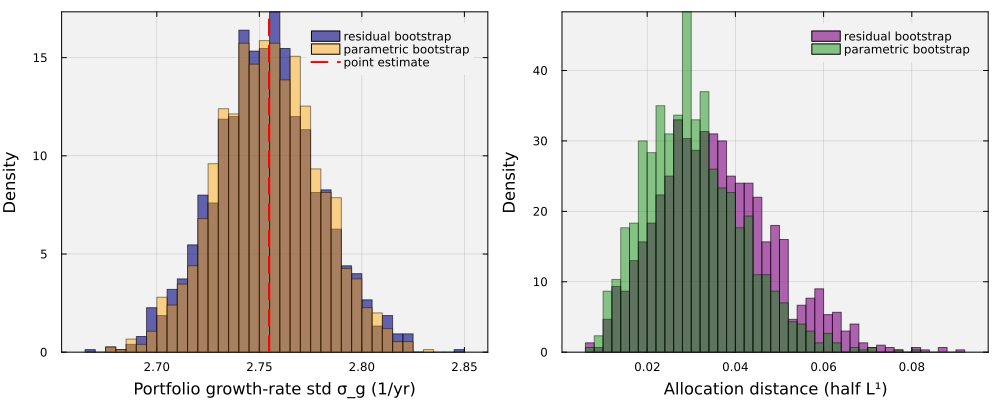

In [7]:
let
    point_σ = let w = residual_propagation.point_weights; sqrt(w'*residual_propagation.point_covariance*w) end;
    p1 = histogram(sqrt.(residual_propagation.fixed_variance), bins = 40, normalize = :pdf, c = :navy, alpha = 0.6, label = "residual bootstrap",
        xlabel = "Portfolio growth-rate std σ_g (1/yr)", ylabel = "Density");
    histogram!(p1, sqrt.(parametric_propagation.fixed_variance), bins = 40, normalize = :pdf, c = :orange, alpha = 0.45, label = "parametric bootstrap");
    vline!(p1, [point_σ], c = :red, lw = 2, ls = :dash, label = "point estimate");
    p2 = histogram(residual_propagation.weight_distance, bins = 40, normalize = :pdf, c = :purple, alpha = 0.6, label = "residual bootstrap",
        xlabel = "Allocation distance (half L¹)", ylabel = "Density");
    histogram!(p2, parametric_propagation.weight_distance, bins = 40, normalize = :pdf, c = :green4, alpha = 0.45, label = "parametric bootstrap");
    plot(p1, p2, layout = (1, 2), size = (1000, 400), bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, left_margin = 4Plots.mm, bottom_margin = 4Plots.mm)
end

### Interpretation and limits
For this six-firm unconstrained GMV portfolio the propagated spread is modest: the fixed portfolio's growth-rate standard deviation moves by a few percent across scenarios, and the scenario-optimal weights sit a few percent of wealth away from the calibrated ones, with a 95% quantile about twice the median. Two things are worth noticing. The portfolio-level numbers cannot be read off the coefficient intervals, because the optimizer is a nonlinear function of all the parameters at once and the covariance inverse weights the residual variances of the least volatile names most heavily; and the GMV portfolio is more stable than a mean-dependent allocation such as the tangent portfolio, because it ignores the mean vector, which L5b's advanced material showed to be the input that destabilizes the tangent portfolio (equal weights, which use no estimate at all, are the extreme case). The gap between the residual and parametric scorecards is a model-risk diagnostic: it measures how much the propagated uncertainty depends on the assumed innovation distribution, and here the heavier-tailed empirical residuals move the weights somewhat more.

Three limits keep this in proportion. What is propagated is __estimation__ uncertainty in the SIM parameters, conditional on the observed market path and on the training-period market moments; it is not a forward scenario for the market. The scenarios draw each asset's bootstrap row __independently__ of the other assets and resample innovations independently across days, so cross-asset residual dependence and the volatility clustering of L3a are outside the exercise, and neither bootstrap reproduces persistent regimes. And the fixed portfolio is the unconstrained GMV portfolio, so the numbers say nothing about how L6b's long-only, target-growth weights would move (that requires re-solving the constrained problem in every scenario, where bounds switching on and off adds a second source of instability). L7b turns to the questions this leaves open: how a fixed allocation drifts, when to rebalance, and what stress scenarios do to it.
___

## Summary
In this notebook, we bootstrapped the single index model parameters of a small universe two ways, kept each asset's joint draw of intercept, beta, and residual scale, rebuilt the SIM covariance for every draw, and read the resulting distributions of a fixed minimum-variance portfolio's risk, its distance from the scenario-optimal weights, and its variance regret.

> __Key Takeaways:__
>
> * **Bootstrap rows are joint draws:** The intercept, beta, and residual scale of one replicate belong together, and preserving that dependence within each asset is what makes a scenario covariance a plausible one; sampling the marginals separately would not.
> * **Uncertainty must reach the decision:** Portfolio variance, optimal weights, allocation distance, and variance regret are nonlinear in all the parameters at once and cannot be read off the coefficient intervals; for an unconstrained GMV portfolio of six firms the propagated spread is modest, and it can be much larger for a mean-dependent allocation such as the tangent portfolio, for a constrained problem whose bounds switch across draws, or when residual dependence is added; nothing here establishes a general rule.
> * **Resampling is not a forward stress test:** The residual-versus-parametric gap exposes sensitivity to the innovation model, but market regimes, factor instability, cross-asset residual dependence, and constraint activity require scenarios this notebook does not draw.

Uncertainty propagation is a decision-level question: whether a portfolio remains acceptable across the parameter draws the data support, not merely whether each coefficient has a narrow interval.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___